## CLASSIFICAÇÃO IRIS - SVC vs SVU

### PARAMETROS

In [209]:
import numpy

In [210]:
# PARÂMETROS
random_seed = 42

# FEATURE SELECTION
center_stat = 'mean'

# C
ensembles = ['ovr', 'ovo']
Cs = [0.001, 0.01, 0.1, 1.0, 10.0]
nakeds = numpy.arange(0.05, 1.0, 0.05)
# gammas = [15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
gammas = [0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0]
kernels = ['sigmoid', 'rbf']
k_of_k_folds = 5

# GOURMET
palette = ['limegreen', 'indianred', 'gold']

In [211]:
from itertools import product
import pandas
import seaborn
from matplotlib import pyplot
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, NuSVC

### IMPORT IRIS

In [212]:
iris_dict = load_iris()
iris = pandas.DataFrame(iris_dict['data'])
iris.columns = iris_dict['feature_names']
iris.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
iris['target'] = iris_dict['target']
iris['species'] = iris['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

iris

,sepal_length,sepal_width,petal_length,petal_width,target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


### PAIRPLOT

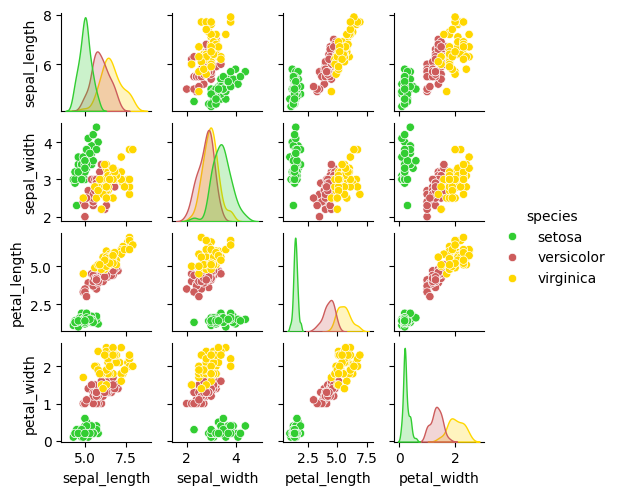

In [213]:
_ = seaborn.pairplot(iris[["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]], hue='species', palette=palette, height=1.25)

### SELEÇÃO DO TOP 2 ATRIBUTOS

In [214]:
all_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
centers = iris.groupby(['species'])[all_cols].agg(center_stat).T
max_diff = (centers.T.max() - centers.T.min()).sort_values(ascending=False)

max_diff

petal_length    4.090
petal_width     1.780
sepal_length    1.582
sepal_width     0.658
dtype: float64

In [215]:
x_cols_sorted = max_diff.index.tolist()[:2]

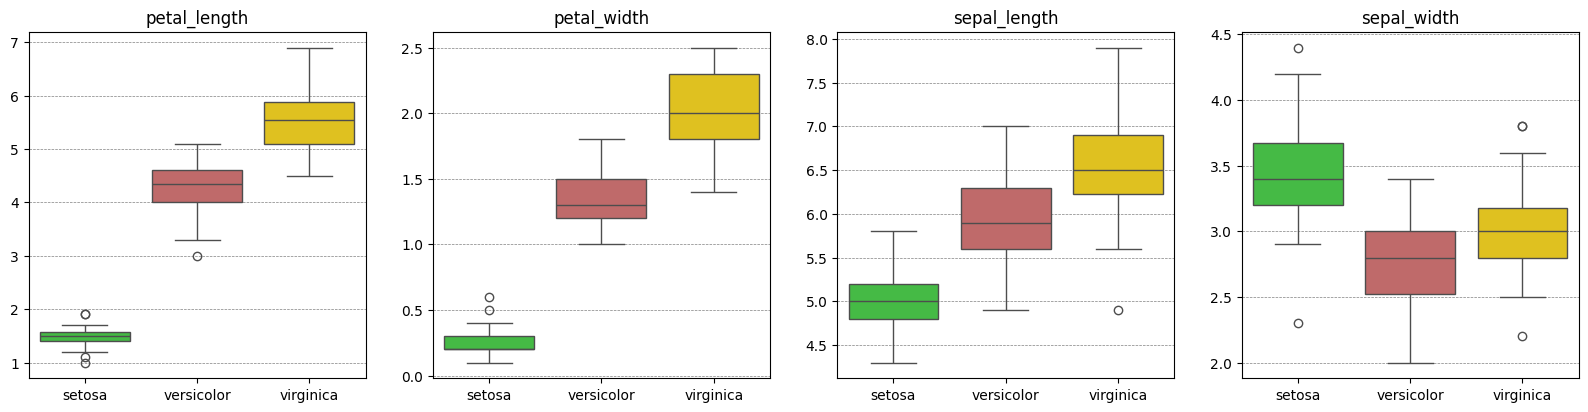

In [216]:
x_cols_sorted = max_diff.index.tolist()

# BOXPLOT DOS ATRIBUTOS VS CLASSE
fig, axs = pyplot.subplots(1, 4, figsize=(20, 4.5))
for i, ax in enumerate(axs.flatten()):
    seaborn.boxplot(x='species', y=x_cols_sorted[i], data=iris, ax=ax, hue='species', dodge=False, palette=palette)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(x_cols_sorted[i])
    ax.grid(which='both', axis='y', color='gray', linestyle='--', linewidth=0.5)

In [217]:
x_cols = x_cols_sorted[:2]

x_cols

['petal_length', 'petal_width']

### LOOP DE TREINAMENTO

> FOLDS VS C VS NU

In [218]:
# RANDOM SEED
numpy.random.seed(random_seed)

# LOOP DE TREINAMENTO
ix_model = 0
model_list = []
kfolds = StratifiedKFold(n_splits=k_of_k_folds, shuffle=True, random_state=random_seed)
for model in ['SVC', 'NuSVC']:
    ix_fold = 0
    for train_ix, val_ix in kfolds.split(iris[x_cols], iris['target']):
        X_train, y_train = iris[x_cols].iloc[train_ix], iris['target'].iloc[train_ix]
        X_val, y_val = iris[x_cols].iloc[val_ix], iris['target'].iloc[val_ix]
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        for ensemble in ensembles:
            for kernel in kernels:
                for gamma in gammas:
                    if model == 'SVC':
                        for C in Cs:
                            svm = SVC(C=C,
                                    kernel=kernel,
                                    gamma=gamma,
                                    class_weight='balanced',
                                    random_state=random_seed,
                                    decision_function_shape=ensemble)
                            svm.fit(X_train_scaled, y_train)
                            y_train_pred = svm.predict(X_train_scaled)
                            y_val_pred = svm.predict(X_val_scaled)
                            train_accuracy = accuracy_score(y_train, y_train_pred)
                            val_accuracy = accuracy_score(y_val, y_val_pred)
                            algorithm = 'SVM'
                            model_name = f"{model}{kernel[:3].upper()}C{C}G{gamma}{ensemble.upper()}{ix_fold}"
                            hyperconfig = f"{kernel[:3].upper()}C{C}G{gamma}{ensemble.upper()}"
                            print(f"{model_name} > treino: {100.0*train_accuracy:.1f}% | val: {100.0*val_accuracy:.1f}%")
                            model_list.append({'ix_model': ix_model,
                                                'algorithm': algorithm,
                                                'model': model,
                                                'model_name': model_name,
                                                'kernel': kernel,
                                                'hyperparameter': C,
                                                'gamma': gamma,
                                                'ensemble': ensemble.upper(),
                                                'hyperconfig' : hyperconfig,
                                                'fold': ix_fold,
                                                'stat' : 'train',
                                                'accuracy': accuracy_score(y_train, y_train_pred),
                                                'scaler' : scaler,
                                                'model' : svm})
                            model_list.append({'ix_model': ix_model,
                                               'algorithm': algorithm,
                                               'model': model,
                                               'model_name': model_name,
                                               'kernel': kernel,
                                               'hyperparameter' : C,
                                               'gamma': gamma,
                                               'ensemble': ensemble.upper(),
                                               'hyperconfig' : hyperconfig,
                                               'fold': ix_fold,
                                               'stat' : 'validation',
                                               'accuracy': accuracy_score(y_val, y_val_pred),
                                               'scaler' : scaler,
                                               'model' : svm})
                            ix_model += 1
                    if model == 'NuSVC':
                        for naked in nakeds:
                            svm = NuSVC(nu=float(naked),
                                        kernel=kernel,
                                        gamma=gamma,
                                        class_weight='balanced',
                                        random_state=random_seed,
                                        decision_function_shape=ensemble)
                            svm.fit(X_train_scaled, y_train)
                            y_train_pred = svm.predict(X_train_scaled)
                            y_val_pred = svm.predict(X_val_scaled)
                            train_accuracy = accuracy_score(y_train, y_train_pred)
                            val_accuracy = accuracy_score(y_val, y_val_pred)
                            algorithm = 'NuSVM'
                            model_name = f"{model}{kernel[:3].upper()}NU{naked:.2f}G{gamma}{ensemble.upper()}{ix_fold}"
                            hyperconfig = f"{kernel[:3].upper()}NU{naked:.2f}G{gamma}{ensemble.upper()}"
                            print(f"{model_name} > treino: {100.0*train_accuracy:.1f}% | val: {100.0*val_accuracy:.1f}%")
                            model_list.append({'ix_model': ix_model,
                                               'algorithm': algorithm,
                                               'model': model,
                                               'model_name': model_name,
                                               'kernel': kernel,
                                               'hyperparameter': naked,
                                               'gamma': gamma,
                                               'ensemble': ensemble.upper(),
                                               'hyperconfig': hyperconfig,
                                               'fold': ix_fold,
                                               'stat': 'train',
                                               'accuracy': accuracy_score(y_train, y_train_pred),
                                               'scaler': scaler,
                                               'model': svm})
                            model_list.append({'ix_model': ix_model,
                                               'algorithm': algorithm,
                                               'model': model,
                                               'model_name': model_name,
                                               'kernel': kernel,
                                               'hyperparameter': naked,
                                               'gamma': gamma,
                                               'ensemble': ensemble.upper(),
                                               'hyperconfig': hyperconfig,
                                               'fold': ix_fold,
                                               'stat': 'validation',
                                               'accuracy': accuracy_score(y_val, y_val_pred),
                                               'scaler': scaler,
                                               'model': svm})
                            ix_model += 1
        ix_fold += 1

SVCSIGC0.001G0.001OVR0 > treino: 95.0% | val: 100.0%
SVCSIGC0.01G0.001OVR0 > treino: 95.0% | val: 100.0%
SVCSIGC0.1G0.001OVR0 > treino: 95.0% | val: 100.0%
SVCSIGC1.0G0.001OVR0 > treino: 95.0% | val: 100.0%
SVCSIGC10.0G0.001OVR0 > treino: 95.0% | val: 100.0%
SVCSIGC0.001G0.01OVR0 > treino: 95.0% | val: 100.0%
SVCSIGC0.01G0.01OVR0 > treino: 95.0% | val: 100.0%
SVCSIGC0.1G0.01OVR0 > treino: 95.0% | val: 100.0%
SVCSIGC1.0G0.01OVR0 > treino: 95.0% | val: 100.0%
SVCSIGC10.0G0.01OVR0 > treino: 95.0% | val: 100.0%
SVCSIGC0.001G0.1OVR0 > treino: 94.2% | val: 100.0%
SVCSIGC0.01G0.1OVR0 > treino: 94.2% | val: 100.0%
SVCSIGC0.1G0.1OVR0 > treino: 94.2% | val: 100.0%
SVCSIGC1.0G0.1OVR0 > treino: 95.0% | val: 100.0%
SVCSIGC10.0G0.1OVR0 > treino: 95.0% | val: 100.0%
SVCSIGC0.001G1.0OVR0 > treino: 70.0% | val: 70.0%
SVCSIGC0.01G1.0OVR0 > treino: 70.0% | val: 70.0%
SVCSIGC0.1G1.0OVR0 > treino: 72.5% | val: 70.0%
SVCSIGC1.0G1.0OVR0 > treino: 62.5% | val: 53.3%
SVCSIGC10.0G1.0OVR0 > treino: 64.2% | val: 

In [219]:
results = pandas.DataFrame(model_list)
results

,ix_model,algorithm,model,model_name,kernel,hyperparameter,gamma,ensemble,hyperconfig,fold,stat,accuracy,scaler
0,0,SVM,"SVC(C=0.001, class_weight='balanced', gamma=0....",SVCSIGC0.001G0.001OVR0,sigmoid,0.001,0.001,OVR,SIGC0.001G0.001OVR,0,train,0.950000,StandardScaler()
1,0,SVM,"SVC(C=0.001, class_weight='balanced', gamma=0....",SVCSIGC0.001G0.001OVR0,sigmoid,0.001,0.001,OVR,SIGC0.001G0.001OVR,0,validation,1.000000,StandardScaler()
2,1,SVM,"SVC(C=0.01, class_weight='balanced', gamma=0.0...",SVCSIGC0.01G0.001OVR0,sigmoid,0.010,0.001,OVR,SIGC0.01G0.001OVR,0,train,0.950000,StandardScaler()
3,1,SVM,"SVC(C=0.01, class_weight='balanced', gamma=0.0...",SVCSIGC0.01G0.001OVR0,sigmoid,0.010,0.001,OVR,SIGC0.01G0.001OVR,0,validation,1.000000,StandardScaler()
4,2,SVM,"SVC(C=0.1, class_weight='balanced', gamma=0.00...",SVCSIGC0.1G0.001OVR0,sigmoid,0.100,0.001,OVR,SIGC0.1G0.001OVR,0,train,0.950000,StandardScaler()
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6715,3357,NuSVM,"NuSVC(class_weight='balanced', decision_functi...",NuSVCRBFNU0.85G50.0OVO4,rbf,0.850,50.000,OVO,RBFNU0.85G50.0OVO,4,validation,0.666667,StandardScaler()
6716,3358,NuSVM,"NuSVC(class_weight='balanced', decision_functi...",NuSVCRBFNU0.90G50.0OVO4,rbf,0.900,50.000,OVO,RBFNU0.90G50.0OVO,4,train,0.891667,StandardScaler()
6717,3358,NuSVM,"NuSVC(class_weight='balanced', decision_functi...",NuSVCRBFNU0.90G50.0OVO4,rbf,0.900,50.000,OVO,RBFNU0.90G50.0OVO,4,validation,0.633333,StandardScaler()
6718,3359,NuSVM,"NuSVC(class_weight='balanced', decision_functi...",NuSVCRBFNU0.95G50.0OVO4,rbf,0.950,50.000,OVO,RBFNU0.95G50.0OVO,4,train,0.891667,StandardScaler()


In [220]:
# fig = pyplot.figure(figsize=(25, 3))
# ax = fig.add_subplot(111)
# _ = seaborn.boxplot(x='hyperconfig', y='accuracy', data=results, hue='stat', palette=['blue', 'green'], ax=ax, hue_order=['train', 'validation'])
# ax.set_title('Comparação dos Hiper-parâmetros')
# ax.set_ylabel('Acurácia')
# ax.set_xlabel('')
# ax.set_ylim(0.0, 1.0)
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
# ax.grid(which='both', color='gray', linestyle='--', linewidth=0.5)

### PICK DO MELHOR MODELO

In [221]:
results

,ix_model,algorithm,model,model_name,kernel,hyperparameter,gamma,ensemble,hyperconfig,fold,stat,accuracy,scaler
0,0,SVM,"SVC(C=0.001, class_weight='balanced', gamma=0....",SVCSIGC0.001G0.001OVR0,sigmoid,0.001,0.001,OVR,SIGC0.001G0.001OVR,0,train,0.950000,StandardScaler()
1,0,SVM,"SVC(C=0.001, class_weight='balanced', gamma=0....",SVCSIGC0.001G0.001OVR0,sigmoid,0.001,0.001,OVR,SIGC0.001G0.001OVR,0,validation,1.000000,StandardScaler()
2,1,SVM,"SVC(C=0.01, class_weight='balanced', gamma=0.0...",SVCSIGC0.01G0.001OVR0,sigmoid,0.010,0.001,OVR,SIGC0.01G0.001OVR,0,train,0.950000,StandardScaler()
3,1,SVM,"SVC(C=0.01, class_weight='balanced', gamma=0.0...",SVCSIGC0.01G0.001OVR0,sigmoid,0.010,0.001,OVR,SIGC0.01G0.001OVR,0,validation,1.000000,StandardScaler()
4,2,SVM,"SVC(C=0.1, class_weight='balanced', gamma=0.00...",SVCSIGC0.1G0.001OVR0,sigmoid,0.100,0.001,OVR,SIGC0.1G0.001OVR,0,train,0.950000,StandardScaler()
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6715,3357,NuSVM,"NuSVC(class_weight='balanced', decision_functi...",NuSVCRBFNU0.85G50.0OVO4,rbf,0.850,50.000,OVO,RBFNU0.85G50.0OVO,4,validation,0.666667,StandardScaler()
6716,3358,NuSVM,"NuSVC(class_weight='balanced', decision_functi...",NuSVCRBFNU0.90G50.0OVO4,rbf,0.900,50.000,OVO,RBFNU0.90G50.0OVO,4,train,0.891667,StandardScaler()
6717,3358,NuSVM,"NuSVC(class_weight='balanced', decision_functi...",NuSVCRBFNU0.90G50.0OVO4,rbf,0.900,50.000,OVO,RBFNU0.90G50.0OVO,4,validation,0.633333,StandardScaler()
6718,3359,NuSVM,"NuSVC(class_weight='balanced', decision_functi...",NuSVCRBFNU0.95G50.0OVO4,rbf,0.950,50.000,OVO,RBFNU0.95G50.0OVO,4,train,0.891667,StandardScaler()


In [222]:
ix_validation = results["stat"] == "validation"

mean_accuracy_by_hyperconfig = results.loc[ix_validation, ["hyperconfig", "accuracy"]].groupby(["hyperconfig"]).agg(["mean", "min"]).reset_index()
mean_accuracy_by_hyperconfig.columns = ['h', 'mean_accuracy', 'min_accuracy']
mean_accuracy_by_hyperconfig = mean_accuracy_by_hyperconfig.sort_values(by=['mean_accuracy', 'min_accuracy'], ascending=[False, False])
mean_accuracy_by_hyperconfig

,h,mean_accuracy,min_accuracy
66,RBFC10.0G20.0OVO,0.986667,0.966667
67,RBFC10.0G20.0OVR,0.986667,0.966667
80,RBFNU0.05G20.0OVO,0.986667,0.966667
81,RBFNU0.05G20.0OVR,0.986667,0.966667
64,RBFC10.0G10.0OVO,0.980000,0.966667
...,...,...,...
413,SIGNU0.05G1.0OVR,0.526667,0.433333
402,SIGC10.0G20.0OVO,0.453333,0.366667
403,SIGC10.0G20.0OVR,0.453333,0.366667
400,SIGC10.0G10.0OVO,0.380000,0.300000


### PICK DO MELHOR MODELO

In [223]:
best_hyperconfig_row = mean_accuracy_by_hyperconfig.iloc[0, :]
best_hyperconfig = best_hyperconfig_row['h']
best_hyperconfig

'RBFC10.0G20.0OVO'

In [224]:
best_h_results = results.loc[results['hyperconfig'] == best_hyperconfig, :]
best_model_rank = best_h_results.pivot(index='model_name', columns='stat', values='accuracy').sort_values(by=['validation', 'train'], ascending=[False, False])
best_model_rank

stat,train,validation
model_name,,
SVCRBFC10.0G20.0OVO0,0.991667,1.000000
SVCRBFC10.0G20.0OVO3,0.991667,1.000000
SVCRBFC10.0G20.0OVO4,0.991667,1.000000
SVCRBFC10.0G20.0OVO2,1.000000,0.966667
SVCRBFC10.0G20.0OVO1,0.991667,0.966667


In [225]:
best_model_row = best_model_rank.iloc[0, :]
best_model_name = best_model_row.name
best_model_name

'SVCRBFC10.0G20.0OVO0'

In [226]:
best_model_row = results.loc[(results['model_name'] == best_model_name) & (results['stat'] == 'validation'), :]
best_model_row

,ix_model,algorithm,model,model_name,kernel,hyperparameter,gamma,ensemble,hyperconfig,fold,stat,accuracy,scaler
269,134,SVM,"SVC(C=10.0, class_weight='balanced', decision_...",SVCRBFC10.0G20.0OVO0,rbf,10.0,20.0,OVO,RBFC10.0G20.0OVO,0,validation,1.0,StandardScaler()


In [227]:
best_model = best_model_row["model"].iloc[0]
best_model_scaler = best_model_row["scaler"].iloc[0]

In [228]:
print(f"Melhor modelo: {best_model_row['model_name'].iloc[0]} > validation: {100.0*best_model_row['accuracy'].iloc[0]:.1f}%")

Melhor modelo: SVCRBFC10.0G20.0OVO0 > validation: 100.0%


### MATRIZ DE CONFUSÃO

In [229]:
Xs = best_model_scaler.transform(iris[x_cols])
y = iris['target'].to_numpy()
winner_y_pred = best_model.predict(Xs)
ok_class = []
for ix in range(len(y)):
    ok_class.append(y[ix] == winner_y_pred[ix])

In [230]:
iris[[not ok for ok in ok_class]]

,sepal_length,sepal_width,petal_length,petal_width,target,species
70,5.9,3.2,4.8,1.8,1,versicolor


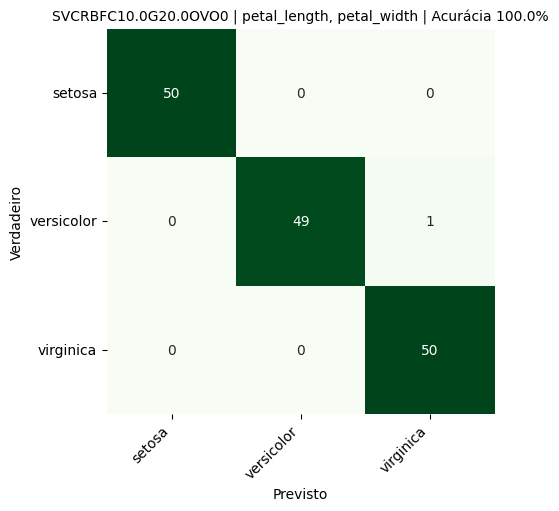

In [231]:
fig = pyplot.figure(figsize=(5, 5))
# PLOT CONFUSION MATRIX
conf_matrix = confusion_matrix(y, winner_y_pred)

ax = fig.add_subplot(111)
_ = seaborn.heatmap(conf_matrix, annot=True, cmap='Greens', cbar=False, ax=ax)
_ = ax.set_xlabel('Previsto')
_ = ax.set_ylabel('Verdadeiro')
_ = ax.set_xticklabels(iris['species'].unique(), rotation=45, ha='right')
_ = ax.set_yticklabels(iris['species'].unique(), rotation=0, ha='right')
# _ = ax.set_title(f'Vencedor: {winner.fk} | treino {100.0*winner_train_accuracy:.0f}% | teste {100.0*winner.hit:.0f}%')
best_feat_string = ', '.join(x_cols)
_ = ax.set_title(f'{best_model_row['model_name'].iloc[0]} | {best_feat_string} | Acurácia {100.0*best_model_row['accuracy'].iloc[0]:.1f}%', size=10)

In [232]:
# CLASS COLOR GRID & CLASS EVALUATION
grid_n_points = 500
species = sorted(iris['species'].unique().tolist())

# X0 W JITTER
X_plot = iris[x_cols].to_numpy()
x0_grid = numpy.linspace(0, X_plot[:, 0].max(), grid_n_points)
x1_grid = numpy.linspace(0, X_plot[:, 1].max(), grid_n_points)
X_g = numpy.array(list(product(x0_grid, x1_grid)))
df_X_g = pandas.DataFrame(X_g, columns=x_cols)
X_g_scaled = best_model_scaler.transform(df_X_g)
Y_g = best_model.predict(X_g_scaled)
Y_g_class = numpy.array([species[x] for x in Y_g])
Y_est = best_model.predict(Xs)
Y_class_est = numpy.array([species[x] for x in Y_est])

In [233]:
species

['setosa', 'versicolor', 'virginica']

In [234]:
color_list = ['steelblue', 'green', 'orange']
background_color_list = ['skyblue', 'limegreen', 'moccasin']
marker_list = ['v', 'o', '^']

# GIVE COLOURS TO CLASS
color_dict = {}
bg_color_dict = {}
marker_dict = {}
ix_color = 0
for specie in species:
    color_dict[specie] = color_list[ix_color]
    marker_dict[specie] = marker_list[ix_color]
    bg_color_dict[specie] = background_color_list[ix_color]
    ix_color += 1

color_dict

{'setosa': 'steelblue', 'versicolor': 'green', 'virginica': 'orange'}

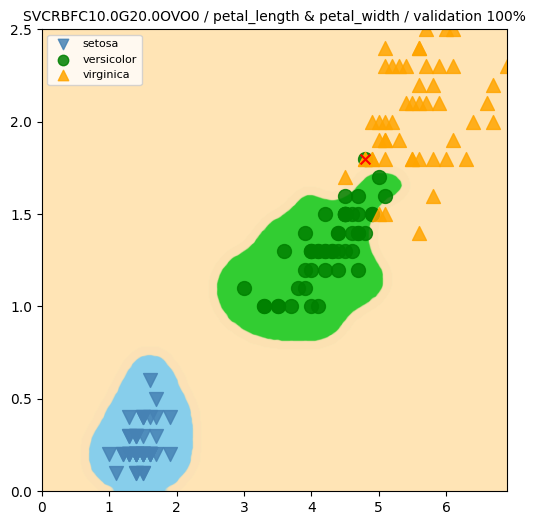

In [235]:
# CLASSIFICATION FIGURE
fig = pyplot.figure(figsize=(6, 6))
ax = fig.add_subplot(111)

# PLOT CLASS REGION
for specie in species:
    ix_class_cloud = Y_g_class == specie
    x_0_cloud = X_g[ix_class_cloud, 0]
    x_1_cloud = X_g[ix_class_cloud, 1]
    _ = ax.scatter(x_0_cloud, x_1_cloud, marker='o', color=bg_color_dict[specie], alpha=0.25)

# PLOR FLOWERS
for specie in species:
    ix_class = iris['species'] == specie
    x_0 = X_plot[ix_class, 0]
    x_1 = X_plot[ix_class, 1]
    _ = ax.scatter(x_0, x_1, color=color_dict[specie], marker=marker_dict[specie], alpha=0.85, s=100, label=specie)
    _ = ax.legend(loc='upper left', fontsize=8, markerscale=0.75)

# PLOT MISCLASSFIED TAG
nok_vectors = X_plot[[not ok for ok in ok_class]]
_ = ax.scatter(nok_vectors[:, 0], nok_vectors[:, 1], color='red', marker='x', s=50, label='Misclassified')

# support_vectors = X_plot[best_model.support_]
# _ = ax.scatter(support_vectors[:, 0], support_vectors[:, 1], color='red', marker='x', s=50, label='Support Vectors')
_ = ax.set_xlim([0.0, X_g[:, 0].max()])
_ = ax.set_ylim([0.0, X_g[:, 1].max()])
_ = ax.set_title(f"{best_model_row['model_name'].iloc[0]} / {' & '.join(x_cols)} / validation {100.0*best_model_row['accuracy'].iloc[0]:.0f}%", size=10)

CONFUSÃO + ROC + SUPERFÍCIE DE SEPARAÇÃO MELHOR MODELO

LEARNING CURVE MELHOR K VS REGRESSÃO LOGÍSTICA

FLUTUAÇÃO DOS PARÂMETROS DA REGRESSÃO LOGÍSTICA